In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# 1. Define file names exactly as you uploaded them
file_mapping = {
    'a_3MeV': 'data/graph_a(3MeV).csv',
    'a_6MeV': 'data/graph_a(6MeV).csv',
    'a_8MeV': 'data/graph_a(8MeV).csv',
    'b_test': 'data/graph_b(test_spectrum_points).csv',
    'b_recon': 'data/graph_b(reconstructed_spectrum_line).csv',
    'c_test': 'data/graph_c(test_spectrum_dashed_line).csv',
    'c_recon': 'data/graph_c(reconstructed_spectrum_solid_line).csv'
}

In [ ]:
# 2. Load and clean the data (Handle missing headers and sort by X-axis)
data = {}
for key, filename in file_mapping.items():
    if os.path.exists(filename):
        # header=None prevents the first data point from becoming the column name
        df = pd.read_csv(filename, header=None)
        df.columns = ['x', 'y']
        # Eliminate duplicate digitizer hits on the same x-pixel by taking the mean
        df = df.groupby('x').mean().reset_index()
        # Sorting by energy ensures lines connect in the correct sequence
        df = df.sort_values(by='x')
        data[key] = df
    else:
        print(f"Warning: {filename} not found in the current directory.")
        data[key] = None

In [4]:
# --- Global Layout Constants for Single Plots ---
FIG_SIZE = (8, 4.5)  # Ideal widescreen ratio for separate panels

Saved: recon_figure_1a.png


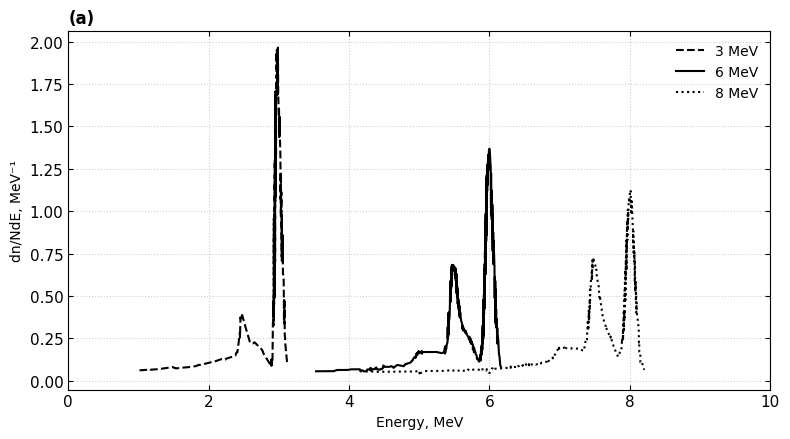

In [5]:
# ==========================================
# 1. GENERATE AND SAVE PLOT (a)
# ==========================================
fig_a, ax_a = plt.subplots(figsize=FIG_SIZE)

if data['a_3MeV'] is not None:
    ax_a.plot(data['a_3MeV']['x'], data['a_3MeV']['y'], linestyle='--', color='black', label='3 MeV')
if data['a_6MeV'] is not None:
    ax_a.plot(data['a_6MeV']['x'], data['a_6MeV']['y'], linestyle='-', color='black', label='6 MeV')
if data['a_8MeV'] is not None:
    ax_a.plot(data['a_8MeV']['x'], data['a_8MeV']['y'], linestyle=':', color='black', label='8 MeV')

ax_a.set_ylabel('dn/NdE, MeV⁻¹')
ax_a.set_xlabel('Energy, MeV')
ax_a.set_title('(a)', loc='left', fontsize=12, fontweight='bold')
ax_a.legend(frameon=False, loc='upper right')
ax_a.grid(True, linestyle=':', alpha=0.6)
ax_a.set_xlim(0, 10)
ax_a.tick_params(direction='in', top=True, right=True, labelsize=11)

plt.tight_layout()
plt.savefig('recon_figure_1a.png', dpi=300)
print("Saved: recon_figure_1a.png")
plt.show()

Saved: recon_figure_1b.png


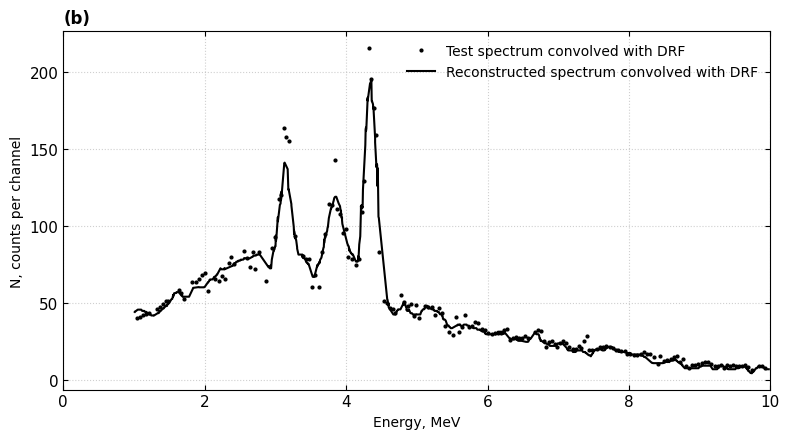

In [6]:
# ==========================================
# 2. GENERATE AND SAVE PLOT (b)
# ==========================================
fig_b, ax_b = plt.subplots(figsize=FIG_SIZE)

if data['b_test'] is not None:
    # Downsample the 5000+ coordinates to plot clear, distinct dots (every 12th point)
    b_test_dots = data['b_test'].iloc[::12]
    ax_b.plot(b_test_dots['x'], b_test_dots['y'], marker='.', linestyle='None', 
              markersize=4, color='black', label='Test spectrum convolved with DRF')

if data['b_recon'] is not None:
    ax_b.plot(data['b_recon']['x'], data['b_recon']['y'], linestyle='-', 
                 color='black', label='Reconstructed spectrum convolved with DRF')

ax_b.set_ylabel('N, counts per channel')
ax_b.set_xlabel('Energy, MeV')
ax_b.set_title('(b)', loc='left', fontsize=12, fontweight='bold')
ax_b.legend(frameon=False, loc='upper right')
ax_b.grid(True, linestyle=':', alpha=0.6)
ax_b.set_xlim(0, 10)
ax_b.tick_params(direction='in', top=True, right=True, labelsize=11)

plt.tight_layout()
plt.savefig('recon_figure_1b.png', dpi=300)
print("Saved: recon_figure_1b.png")
plt.show()

Saved: recon_figure_1c.png


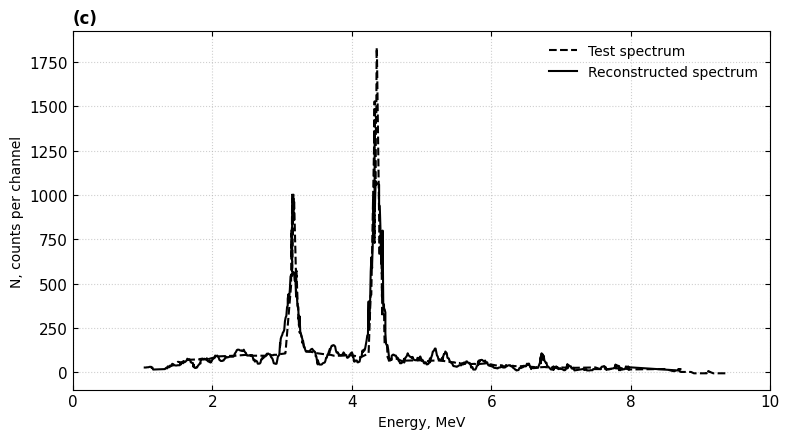

In [7]:
# ==========================================
# 3. GENERATE AND SAVE PLOT (c)
# ==========================================
fig_c, ax_c = plt.subplots(figsize=FIG_SIZE)

if data['c_test'] is not None:
    ax_c.plot(data['c_test']['x'], data['c_test']['y'], linestyle='--', 
                 color='black', label='Test spectrum')
if data['c_recon'] is not None:
    ax_c.plot(data['c_recon']['x'], data['c_recon']['y'], linestyle='-', 
                 color='black', label='Reconstructed spectrum')

ax_c.set_ylabel('N, counts per channel')
ax_c.set_xlabel('Energy, MeV')
ax_c.set_title('(c)', loc='left', fontsize=12, fontweight='bold')
ax_c.legend(frameon=False, loc='upper right')
ax_c.grid(True, linestyle=':', alpha=0.6)
ax_c.set_xlim(0, 10)
ax_c.tick_params(direction='in', top=True, right=True, labelsize=11)

plt.tight_layout()
plt.savefig('recon_figure_1c.png', dpi=300)
print("Saved: recon_figure_1c.png")
plt.show()